In [200]:
# import os
# import sys
# sys.path.insert(1, os.path.abspath(os.path.join('..', 'src')))

import jax

import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt

from scipy.optimize import linprog

# AGOP of L1 linear regressors

We can generate multiple Bayes predictors by generating population distribution with multiple medians: $$f(x) = \theta^T x + \sigma \quad \sigma \sim \operatorname{Rad}(\frac12)$$

In [137]:
key = jax.random.key(33)

n = 100
d = 1

In [168]:
key_model, key_data = jr.split(key, 2)
theta = jr.multivariate_normal(key_model, mean=jnp.zeros(d+1), cov=jnp.eye(d+1))
theta = jnp.array([1.0, -1.0])

X = jr.multivariate_normal(key_data, mean=jnp.zeros(d), cov=jnp.eye(d), shape=(n,))


In [169]:
theta

Array([ 1., -1.], dtype=float32)

In [170]:
X_bias = jnp.concatenate([X, jnp.ones((n,1))], axis=1)

In [175]:
def f(key, theta):
    return lambda X : X @ theta + jr.rademacher(key, shape=(X.shape[0],))

In [176]:
key_model, _ = jr.split(key_model)

target_fn = f(key_model, theta)

In [177]:
Y = target_fn(X_bias)

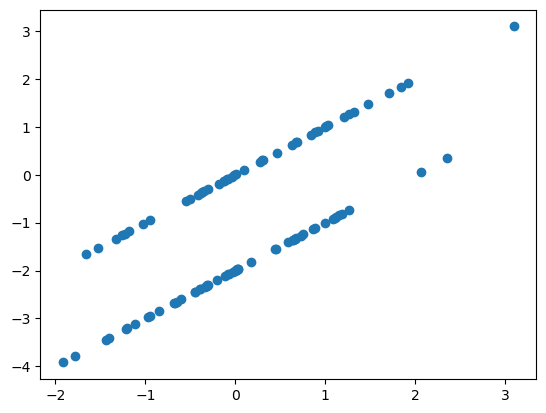

In [179]:
plt.plot(X, Y, 'o')

### First check least squares predictor

In [202]:
cov = X_bias.T @ X_bias
b = X_bias.T @ Y

F = jnp.linalg.cholesky(cov)

z = jnp.linalg.solve(F, b)
theta_l2 = jnp.linalg.solve(F.T, z)

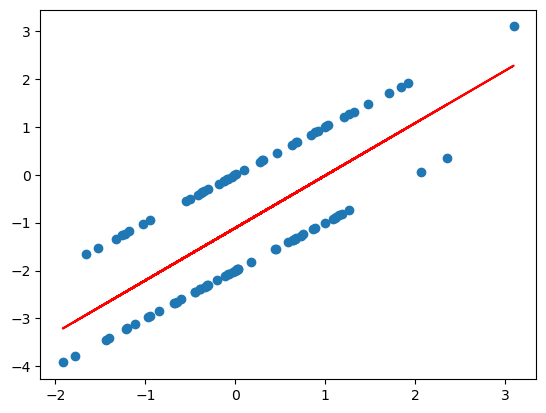

In [203]:
plt.plot(X, Y, 'o')
plt.plot(X, X_bias @ theta_l2, 'r')

### Next check the L1 regression estimate solved by linear programming

In [218]:
c = jnp.concatenate([jnp.zeros_like(theta), jnp.ones(n)])

A = jnp.block([
    [X_bias,  -jnp.eye(n)], 
    [-X_bias, -jnp.eye(n)]
])
b = jnp.concatenate([Y, - Y])

# bounds = (d+1) * [(None, None)] + n * [(0, None)]

res = linprog(c, A_ub=A, b_ub=b, method="highs")
theta_l1 = res.x[:d+1]

In [234]:
theta_l1

array([1., 0.])

In [241]:
theta_lower = jnp.array([1.0, -2.0])

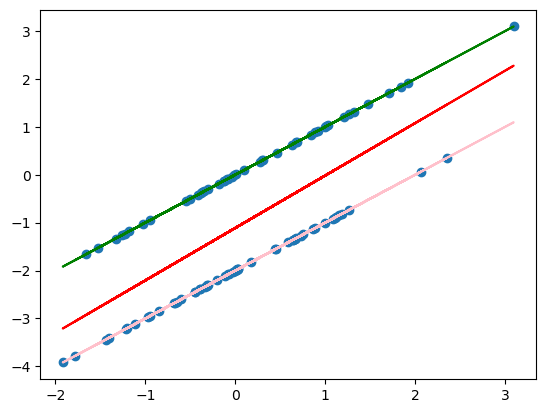

In [242]:
plt.plot(X, Y, 'o')
plt.plot(X, X_bias @ theta_l2, 'r')
plt.plot(X, X_bias @ theta_l1, 'g')
plt.plot(X, X_bias @ theta_lower, 'pink')

In [243]:
true_agop  =  jnp.outer(theta, theta)
l2_agop    =  jnp.outer(theta_l2, theta_l2)
l1_agop    =  jnp.outer(theta_l1, theta_l1)
lower_agop =  jnp.outer(theta_lower, theta_lower)

In [244]:
true_agop, l2_agop, l1_agop, lower_agop

(Array([[ 1., -1.],
        [-1.,  1.]], dtype=float32),
 Array([[ 1.197684 , -1.215085 ],
        [-1.215085 ,  1.2327387]], dtype=float32),
 Array([[1., 0.],
        [0., 0.]], dtype=float32),
 Array([[ 1., -2.],
        [-2.,  4.]], dtype=float32))

In [245]:
true_eigenvals, true_eigenvecs = jnp.linalg.eig(true_agop)
l2_eigenvals, l2_eigenvecs     = jnp.linalg.eig(l2_agop)
l1_eigenvals, l1_eigenvecs     = jnp.linalg.eig(l1_agop)
lower_eigenvals, lower_eigenvecs = jnp.linalg.eig(lower_agop)

In [247]:
true_eigenvals, true_eigenvecs, l2_eigenvals, l2_eigenvecs, l1_eigenvals, l1_eigenvecs, lower_eigenvals, lower_eigenvecs

(Array([2.+0.j, 0.+0.j], dtype=complex64),
 Array([[ 0.70710677+0.j,  0.70710677+0.j],
        [-0.70710677+0.j,  0.70710677+0.j]], dtype=complex64),
 Array([-1.1920929e-07+0.j,  2.4304228e+00+0.j], dtype=complex64),
 Array([[-0.71218795+0.j,  0.7019889 +0.j],
        [-0.7019889 +0.j, -0.71218795+0.j]], dtype=complex64),
 Array([1.+0.j, 0.+0.j], dtype=complex64),
 Array([[1.+0.j, 0.+0.j],
        [0.+0.j, 1.+0.j]], dtype=complex64),
 Array([0.+0.j, 5.+0.j], dtype=complex64),
 Array([[-0.8944272+0.j,  0.4472136+0.j],
        [-0.4472136+0.j, -0.8944272+0.j]], dtype=complex64))

In [248]:
sum(jnp.sqrt(true_eigenvals)).real, sum(jnp.sqrt(l2_eigenvals)).real, sum(jnp.sqrt(l1_eigenvals).real), sum(jnp.sqrt(lower_eigenvals).real)

(Array(1.4142135, dtype=float32),
 Array(1.5589813, dtype=float32),
 Array(1., dtype=float32),
 Array(2.236068, dtype=float32))

In [249]:
sum(jnp.abs(true_eigenvals)).real, sum(jnp.abs(l2_eigenvals)).real, sum(jnp.abs(l1_eigenvals).real), sum(jnp.abs(lower_eigenvals).real)

(Array(2., dtype=float32),
 Array(2.4304228, dtype=float32),
 Array(1., dtype=float32),
 Array(5., dtype=float32))

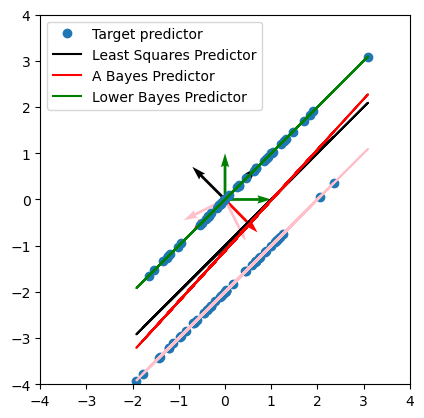

In [ ]:
from sklearn.preprocessing import scale


plt.plot(X, Y, 'o')
plt.plot(X, X_bias @ theta, 'k')
plt.plot(X, X_bias @ theta_l2, 'r')
plt.plot(X, X_bias @ theta_l1, 'g')
plt.plot(X, X_bias @ theta_lower, 'pink')

# 
plt.quiver(0, 0, true_eigenvecs[0][0], true_eigenvecs[1][0], angles='xy', scale_units='xy', scale=1, color='k', label='_nolegend_')
plt.quiver(0, 0, true_eigenvecs[0][1], true_eigenvecs[1][1], angles='xy', scale_units='xy', scale=1, color='k', label='_nolegend_')

plt.quiver(0, 0, l2_eigenvecs[0][0], l2_eigenvecs[1][0], angles='xy', scale_units='xy', scale=1, color='r', label='_nolegend_')
plt.quiver(0, 0, l2_eigenvecs[0][1], l2_eigenvecs[1][1], angles='xy', scale_units='xy', scale=1, color='r', label='_nolegend_')

plt.quiver(0, 0, l1_eigenvecs[0][0], l1_eigenvecs[1][0], angles='xy', scale_units='xy', scale=1, color='g', label='_nolegend_')
plt.quiver(0, 0, l1_eigenvecs[0][1], l1_eigenvecs[1][1], angles='xy', scale_units='xy', scale=1, color='g', label='_nolegend_')

plt.quiver(0, 0, lower_eigenvecs[0][0], lower_eigenvecs[1][0], angles='xy', scale_units='xy', scale=1, color='pink', label='_nolegend_')
plt.quiver(0, 0, lower_eigenvecs[0][1], lower_eigenvecs[1][1], angles='xy', scale_units='xy', scale=1, color='pink', label='_nolegend_')

plt.legend(['Target predictor', 'Least Squares Predictor', 'A Bayes Predictor', 'Lower Bayes Predictor'], loc='upper left')

plt.xlim(-4, 4)
plt.ylim(-4, 4)
plt.gca().set_aspect('equal', adjustable='box')